In [1]:
from lib_analysis import *
%matplotlib inline

cm_inferno = plt.cm.get_cmap('inferno') 

cat_lolss = isolated(Table.read('../LoLSS_DR1_rolling.srl.fits'), dist=15*2)
cat_lotss = isolated(Table.read('../LoTSS-cut.fits'), dist=15*2)
cat_lotss.rename_column('Total_flux', 'flux_lotss')
cat_lotss.rename_column('Peak_flux', 'peak_lotss')
cat_lotss.rename_column('E_Total_flux', 'flux_lotss_e')

# restrict to compact for lotss (will be used later)
snr = cat_lotss['flux_lotss']/cat_lotss['flux_lotss_e']
R = 0.42+(1.08/( 1 + (snr/96.57)**(2.49) ))
cat_lotss['is_pnt'] = (R > np.log(cat_lotss['flux_lotss']/cat_lotss['peak_lotss'])) 
print('Is pnt (LoTSS) %f%%' % (100*sum(cat_lotss['is_pnt'])/len(cat_lotss)))

cat_full = cross_match(cat_lolss, cat_lotss, dist=15, columns_to_keep=['flux_lotss','is_pnt'])
print('Match LoTSS: %i' % sum(cat_full['flux_lotss'] != 0))
print('un-Match LoTSS: %i' % sum(cat_full['flux_lotss'] == 0))
print('Is pnt %f%%' % (100*sum(cat_full['is_pnt'])/len(cat_full))) # this only means LoLSS is sensitive to nearby+extended objects
print('Is png and Scode=S and Maj<30 %f%%' % (100*sum((cat_full['is_pnt']) & (cat_full['S_Code'] == 'S') & (cat_full['Maj'] < 30)
)/len(cat_full)))

Removing 339 out of 42463 source
Removing 237344 out of 932316 source
Is pnt (LoTSS) 94.403516%
Match LoTSS: 30954
un-Match LoTSS: 11170
Is pnt 51.687874%
Is png and Scode=S and Maj<30 46.878264%


Binned means 1: [0.35891867 0.45234668 0.48302251 0.50385398 0.43326753 0.38879031
 0.36314744 0.15701848 0.11034475]
Binned means 2: [0.31930068 0.33500451 0.32578331 0.31185025 0.28551897 0.25700068
 0.21285184 0.16426343 0.15223452 0.13025728 0.12890834 0.10267733
 0.11854653 0.10376499]
Fit coeff: [ 0.54412084  2.56226086 55.99896877  0.1814173 ] 2
R_{95} = 0.181417 + \left( \frac{0.725538}{1+\left( \frac{\rm SNR}{55.998969} \right)^{2.562261}} \right)
Sources above the pntsrc line: 9170 (21.77%)


/tmp/ipykernel_601299/2182719786.py:76: RuntimeWarning: invalid value encountered in power
  return abs(coeffs[3] + (coeffs[0] + coeffs[3])/(1+(x/coeffs[2])**(coeffs[1])))


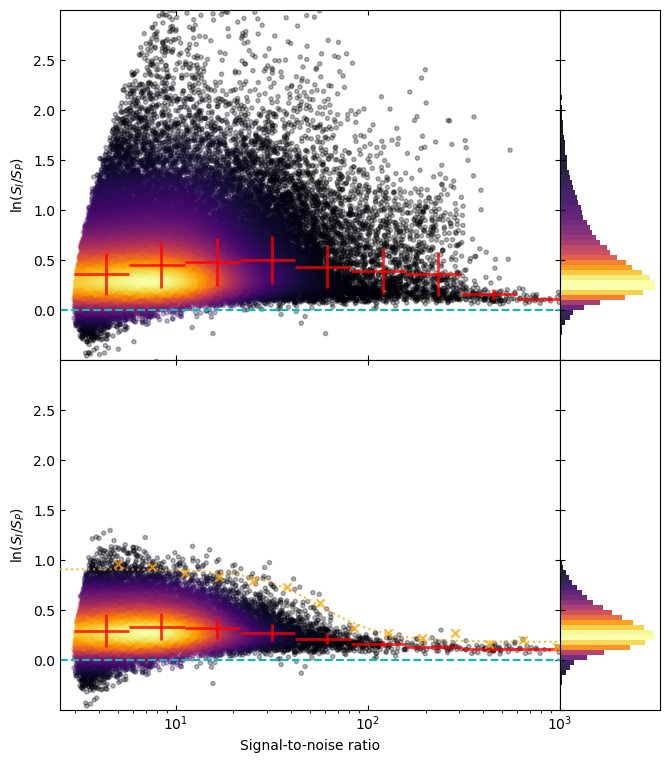

In [2]:
def binning(x,y,nbins,bin_equal_n=True):
    """
    bin_equal_n: if True divide the sample in bins with equal number of objects
    if False, divide in bins equally spaced in log space
    """
    import scipy.stats as stats
    if bin_equal_n: bins = stats.mstats.mquantiles(x, np.linspace(0,1,nbins+1))
    else: bins = np.logspace(np.log10(min(x)), np.log10(max(x)), num=nbins)
    bin_med, bin_edges, binnumber = stats.binned_statistic(x, y, statistic='median', bins=bins)
    bin_std, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=median_absolute_deviation, bins=bins)
    bin_95, bin_edges, binnumber = stats.binned_statistic(x, y, statistic=lambda y: np.percentile(y, 99), bins=bins)
    bin_width = (bin_edges[1:] - bin_edges[:-1])
    bin_centers = bin_edges[1:] - bin_width/2
    return bin_centers, bin_width, bin_med, bin_std, bin_95

def fit_pnt(x,y):
    from scipy.optimize import curve_fit
    def func(x, a, b, c):
        return 

is_pnt = (cat_full['is_pnt']) & (cat_full['S_Code'] == 'S') & (cat_full['Maj'] < 30)

# definitions for the axes
left, width = 0.1, 1.0
bottom, height = 0.1, 0.5
spacing = 0.00
rect_scatter1 = [left, bottom + height, width, height]
rect_histy1 = [left + width + spacing, bottom + height, 0.2, height]
rect_scatter2 = [left, bottom, width, height]
rect_histy2 = [left + width + spacing, bottom, 0.2, height]

fig = plt.figure(figsize=(5, 7))

ax1 = plt.axes(rect_scatter1)
ax1.tick_params(direction='in', top=True, right=True)
ax1_histy = plt.axes(rect_histy1)
ax1_histy.tick_params(direction='in', labelleft=False)

ax2 = plt.axes(rect_scatter2)
ax2.tick_params(direction='in', top=True, right=True)
ax2_histy = plt.axes(rect_histy2)
ax2_histy.tick_params(direction='in', labelleft=False)

fig.subplots_adjust(hspace=0)

ax2.set_xlabel(r'Signal-to-noise ratio')
ax1.set_ylabel(r'$\ln(S_I / S_P)$')
ax2.set_ylabel(r'$\ln(S_I / S_P)$')

all_int_to_peak = []
# find int to peak ratio
int_to_peak = np.log(cat_full['Total_flux']/cat_full['Peak_flux'])
# find the S/N
snratio = cat_full['Total_flux']/cat_full['E_Total_flux']

xy = np.vstack([snratio,int_to_peak])
z = gaussian_kde(xy)(xy)
ax1.scatter(snratio,int_to_peak, marker='.', c=z, cmap=cm.inferno, alpha=.3)

xy = np.vstack([snratio[is_pnt],int_to_peak[is_pnt]])
z = gaussian_kde(xy)(xy)
ax2.scatter(snratio[is_pnt],int_to_peak[is_pnt], marker='.', c=z, cmap=cm.inferno, alpha=.3)

# add average values
bin_centers, bin_width, bin_med, bin_std, bin_95 = binning(snratio, int_to_peak, nbins=10, bin_equal_n=False)
ax1.errorbar(bin_centers, bin_med, xerr=bin_width/2., yerr=bin_std, color='r', zorder=100, ls='', lw=2, alpha=0.8)
print('Binned means 1:', bin_med)
bin_centers, bin_width, bin_med, bin_std, bin_95 = binning(snratio[is_pnt], int_to_peak[is_pnt], nbins=10, bin_equal_n=False)
ax2.errorbar(bin_centers, bin_med, xerr=bin_width/2., yerr=bin_std, color='r', zorder=100, ls='', lw=2, alpha=0.8)
selection = (is_pnt & (snratio > 4))
bin_centers, bin_width, bin_med, bin_std, bin_95 = binning(snratio[selection], int_to_peak[selection], nbins=15, bin_equal_n=False)
ax2.scatter(bin_centers, bin_95, color='orange', zorder=100, marker='x', alpha=0.8)
print('Binned means 2:', bin_med)

def model(x, coeffs):
    return abs(coeffs[3] + (coeffs[0] + coeffs[3])/(1+(x/coeffs[2])**(coeffs[1])))
def residuals(coeffs, y, x):
    return y - model(x, coeffs)

x0 = [0.7,2.0,100.0,0.4]
xcoeff, flag = scipy.optimize.leastsq(residuals, x0, args=(bin_95, bin_centers), epsfcn=1)
print("Fit coeff:", xcoeff, flag)
print('R_{95} = %f + \\left( \\frac{%f}{1+\\left( \\frac{\\rm SNR}{%f} \\right)^{%f}} \\right)' % (xcoeff[3],xcoeff[0]+xcoeff[3],xcoeff[2],xcoeff[1]))
xpoints = np.logspace(np.log10(2.5),np.log10(1000))
ax2.plot(xpoints, model(xpoints, xcoeff), color='orange', zorder=100, ls=':', marker='', alpha=0.8)

pnt = int_to_peak > model(snratio, xcoeff)
pnt_frac = np.sum(pnt)/len(int_to_peak)*100
print("Sources above the pntsrc line: %i (%.2f%%)" % (np.sum(pnt), pnt_frac))

# histograms
bins = np.arange(-1, 4 + 0.1, 0.05)
n, bins, patches = ax1_histy.hist(int_to_peak, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
ax1_histy.set_xticks([], minor=[])
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm_inferno(c))
    
n, bins, patches = ax2_histy.hist(int_to_peak[is_pnt], bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar')
ax2_histy.set_xticks([], minor=[])
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm_inferno(c))
    
ax1.set_xlim(xmin=2.5,xmax=1000)
ax1.set_ylim(ymin=-0.5,ymax=3)
ax1.set_xscale('log')
ax2.set_xlim(xmin=2.5,xmax=1000)
ax2.set_ylim(ymin=-0.5,ymax=3)
ax2.set_xscale('log')
ax1_histy.set_ylim(ax1.get_ylim())
ax2_histy.set_ylim(ax2.get_ylim())
ax1.axhline(0, ls="--", color='c')
ax2.axhline(0, ls="--", color='c')
#ax1.grid(alpha=.2)
#ax2.grid(alpha=.2)
ax1.set_yticks([0,0.5,1,1.5,2,2.5])
ax2.set_yticks([0,0.5,1,1.5,2,2.5])
fig.savefig('inttopeak.png', bbox_inches='tight', dpi=200)

Initial len: 42463 (ref:946432)
Removing 1688 out of 42463 source
Removing 128588 out of 946432 source
After isaolated sources len: 40775 (ref:817844)
Is pnt 78.261189%
After compact source len: 31911 (ref:537033)
Sep MAD: 0.824033"
Sep MAD: 0.612643"
Sep MAD: 0.603302"
Sep MAD: 0.602903"
After match source len: 12870
mean = -0.08" 0.04" - std = 1.48" 1.17"
-0.07537668396857025 1.4753457085508241


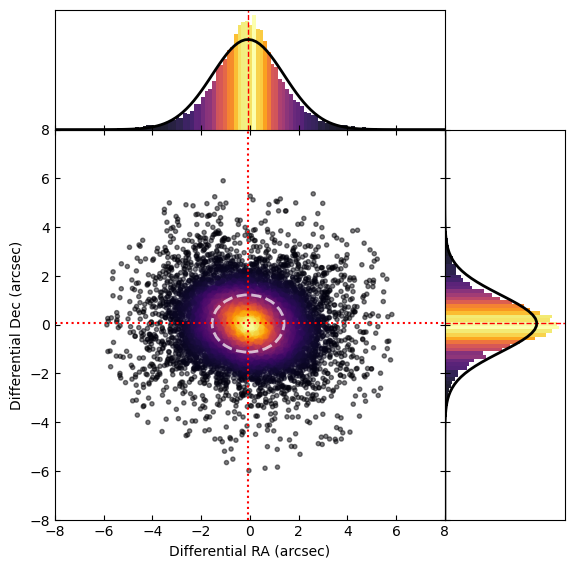

In [3]:
# check accuracy in astrometry
# - use FIRST
# - use only point sources in LBA
# - limit to isolated point sources in FIRST and LOFAR

beam_lofar = 15 # arcsec
cat_ref = '/home/fdg/phd/obs/catalogues/FIRST_14dec17.fits.gz'
cat_lolss = '../LoLSS_DR1_rolling.srl.fits'
ref_t = Table.read(cat_ref)
img_t = Table.read(cat_lolss)
print('Initial len: %i (ref:%i)' % (len(img_t),len(ref_t)))

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.00
rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(hspace=0)

ax = plt.axes(rect_scatter)
ax.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)
ax.set_xlabel(r'Differential RA (arcsec)')
ax.set_ylabel(r'Differential Dec (arcsec)')

# reduce to isolated sources LOFAR
img_t = isolated(img_t, 3*beam_lofar)
# reduce to isolated sources REF
ref_t = isolated(ref_t, beam_lofar)
print('After isaolated sources len: %i (ref:%i)' % (len(img_t),len(ref_t)))

# restrict to compact
snr = img_t['Total_flux']/img_t['E_Total_flux']
R = xcoeff[3] + (xcoeff[0] + xcoeff[3])/(1+(snr/xcoeff[2])**(xcoeff[1]))
img_t['is_pnt'] = (R > np.log(img_t['Total_flux']/img_t['Peak_flux'])) 
print('Is pnt %f%%' % (100*sum(img_t['is_pnt'])/len(img_t)))
img_t = img_t[img_t['is_pnt']]
ref_t = ref_t[ (ref_t['FINT']/ref_t['FPEAK']) < 1.2 ]
print('After compact source len: %i (ref:%i)' % (len(img_t),len(ref_t)))

# cross match
idx_match, sep, _ = match_coordinates_sky(SkyCoord(img_t['RA'], img_t['DEC']),\
                                          SkyCoord(ref_t['RA'], ref_t['DEC']))

sep_mad = median_absolute_deviation(sep[np.where(sep < 100*u.arcsec)])
sep_mad_old = 0
    
while sep_mad != sep_mad_old:
    print('Sep MAD: %f"' % sep_mad.arcsec)
    sep_mad_old = sep_mad
    sep_mad = median_absolute_deviation(sep[np.where(sep < 10 * sep_mad)])
sep_mad *= 10 # keep those within 10 times MAD

idx_match_ref = idx_match[sep<sep_mad]
idx_match_img = np.arange(0,len(img_t))[sep<sep_mad]
img_t = img_t[idx_match_img]

print('After match source len: %i' % len(img_t))

ddec = ref_t['DEC'][idx_match_ref] - img_t['DEC']
dra = (ref_t['RA'][idx_match_ref] - img_t['RA']) * np.cos(img_t['DEC']*np.pi/180.)
dra[ dra>180 ] -= 360
dra[ dra<-180 ] += 360

meandra = np.mean(dra*3600)
meanddec = np.mean(ddec*3600)
stddra = np.std(dra*3600)
stdddec = np.std(ddec*3600)

print ('mean = %.2f" %.2f" - std = %.2f" %.2f"' % (meandra, meanddec, stddra, stdddec))
    
# Calculate the point density
xy = np.vstack([dra,ddec])
z = gaussian_kde(xy)(xy)
ax.scatter(dra*3600, ddec*3600, marker='.', c=z, cmap=cm.inferno, alpha=.5)
ax.set_xlim(xmin=-8,xmax=8)
ax.set_ylim(ymin=-8,ymax=8)

# add ellipses
ax.add_artist(Ellipse(xy=[meandra,meanddec], width=2*stddra, height=2*stdddec, angle=0, alpha=.7, color='white', fill=False, ls='--', lw=2))

# histograms
bins = np.arange(-8, 8 + 0.5, 0.15)
n, bins, patches = ax_histx.hist(dra*3600, bins=bins, color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm_inferno(c))
n, bins, patches = ax_histy.hist(ddec*3600, bins=bins, orientation='horizontal', color='black', alpha=0.9, histtype='bar', density=True)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    p.set_facecolor(cm_inferno(c))
ax_histx.axvline(meandra, color='r', linestyle='dashed', linewidth=1)
ax_histy.axhline(meanddec, color='r', linestyle='dashed', linewidth=1)

# gaussian fit
(ra_mu, ra_sigma) = norm.fit(dra*3600)
print(ra_mu, ra_sigma)
gaus = norm.pdf( bins, ra_mu, ra_sigma)
l = ax_histx.plot(bins, gaus, 'k-', linewidth=2)
(dec_mu, dec_sigma) = norm.fit(ddec*3600)
gaus = norm.pdf( bins, dec_mu, dec_sigma)
l = ax_histy.plot(gaus, bins, 'k-', linewidth=2)

ax_histx.set_yticks([], [])
ax_histy.set_xticks([], [])

ax_histx.set_xlim(ax.get_xlim())
ax_histy.set_ylim(ax.get_ylim())

ax.axvline(meandra, ls=":", color='r')
ax.axhline(meanddec, ls=":", color='r')

#ax.grid(alpha=.2)

fig.savefig('astrometry.pdf', bbox_inches='tight', facecolor='w')